In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm  # Import tqdm
import random


In [6]:
def sis_sim(graph, beta, gamma, seed, max_steps=1000):
    random.seed(seed)
    p = random.uniform(0, 1)

    nodes = set(graph.nodes)
    infected_nodes = set(random.sample(nodes, int(p * len(nodes))))
    susceptible_nodes = nodes - infected_nodes

    step = 0
    while step < max_steps:
        infected_nodes_copy = infected_nodes.copy()
        susceptible_nodes_copy = susceptible_nodes.copy()

        for node in susceptible_nodes_copy:
            neighbors = set(graph.neighbors(node))
            infected_neighbors = neighbors & infected_nodes_copy

            num_infected_neighbors = len(infected_neighbors)
            prob_infection = 1 - (1 - beta) ** num_infected_neighbors
            if random.uniform(0, 1) < prob_infection:
                infected_nodes.add(node)
                susceptible_nodes.remove(node)

        for node in infected_nodes_copy:
            if random.uniform(0, 1) < gamma:
                infected_nodes.remove(node)
                susceptible_nodes.add(node)

        step += 1

    return len(infected_nodes) / len(nodes)

In [7]:
def average_sis_sim(graph, beta, gamma, sample_size=100, seed=None):
    results = [sis_sim(graph, beta, gamma, seed, max_steps=1000) for _ in tqdm(range(sample_size), desc="Average Simulation Progress")]
    return np.mean(results)

def calculate_critical_er_threshold(graph):
    total_degree = sum(dict(graph.degree()).values())
    avg_degree = total_degree / len(graph)
    return 1 / (avg_degree + 1)

def calculate_critical_ba_threshold(graph):
    degrees = dict(graph.degree())
    total_nodes = len(graph)
    
    avg_degree = sum(degrees.values()) / total_nodes
    avg_square_degree = sum(degree ** 2 for degree in degrees.values()) / total_nodes
    
    return avg_degree / avg_square_degree


Average Simulation Progress: 100%|██████████| 100/100 [00:51<00:00,  1.93it/s]


Execution time: 1147.96 seconds


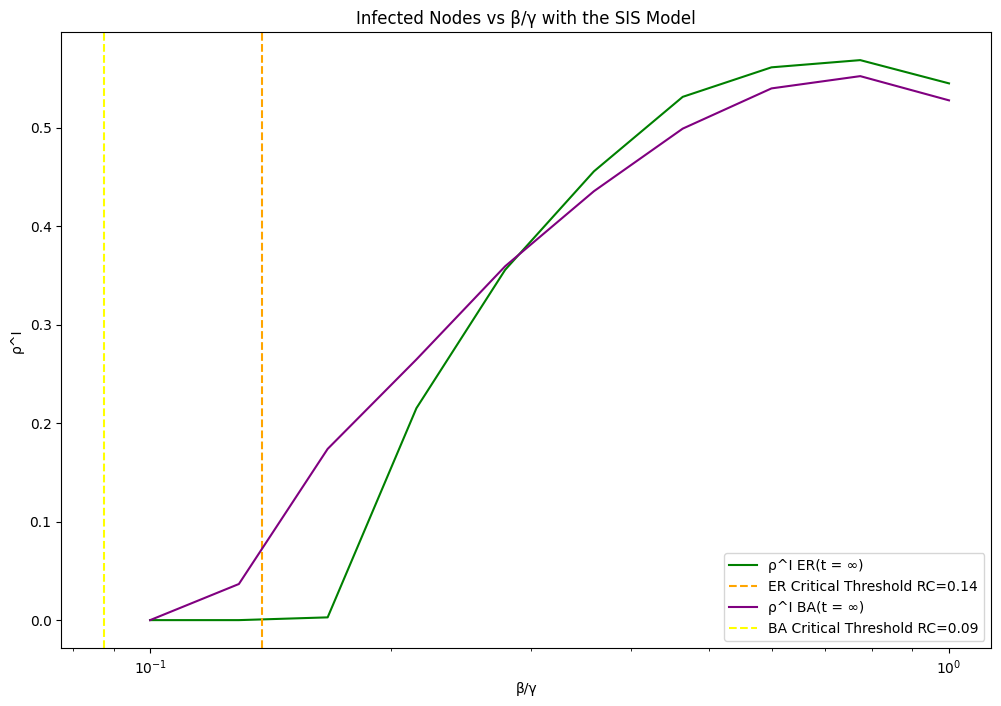

In [8]:
# Param
beta_gamma_values = np.logspace(-1, 0, 10)
gamma_values = np.logspace(-1, -0.1, 10)
beta_values = beta_gamma_values * gamma_values
sample_size = 100

# Erdos-Renyi 
Ner = 500
per = 6 / Ner
er_graph = nx.erdos_renyi_graph(Ner, per)

# Barabasi-Albert
Nba = 500
mba = 3
ba_graph = nx.barabasi_albert_graph(Nba, mba)

# Initialize timer
start_time = time.time()

# Perform sim and calculate averages for ER graph
rho_i_er = []
for beta, gamma in zip(beta_values, gamma_values):
    result_er = average_sis_sim(er_graph, beta, gamma, sample_size)
    rho_i_er.append(result_er)

# Perform sim and calculate averages for BA graph
rho_i_ba = []
for beta, gamma in zip(beta_values, gamma_values):
    result_ba = average_sis_sim(ba_graph, beta, gamma, sample_size)
    rho_i_ba.append(result_ba)


# Calculate critical thresholds
rc_er = calculate_critical_er_threshold(er_graph)
rc_ba = calculate_critical_ba_threshold(ba_graph)

# Print execution time
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.2f} seconds")

# Plot
plt.figure(figsize=(12, 8))  
plt.plot(beta_gamma_values, rho_i_er, label=f'ρ^I ER(t = ∞)', color='green')  
plt.axvline(x=rc_er, color='orange', linestyle='--', label=f'ER Critical Threshold RC={rc_er:.2f}')  
plt.plot(beta_gamma_values, rho_i_ba, label=f'ρ^I BA(t = ∞)', color='purple')  
plt.axvline(x=rc_ba, color='yellow', linestyle='--', label=f'BA Critical Threshold RC={rc_ba:.2f}') 

plt.xscale('log')
plt.xlabel('β/γ')
plt.ylabel('ρ^I')
plt.title('Infected Nodes vs β/γ with the SIS Model')
plt.legend()
plt.show()